## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D) 

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들) 
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [2]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
import ssl
import certifi

# certifi의 CA 인증서 묶음을 명시적으로 사용
ssl._create_default_https_context = lambda: ssl.create_default_context(
    cafile=certifi.where()
)

print("사용할 인증서 파일:", certifi.where())

사용할 인증서 파일: c:\Users\User\anaconda3\envs\d2l\Lib\site-packages\certifi\cacert.pem


100%|██████████| 170M/170M [33:07<00:00, 85.8kB/s]   
100%|██████████| 170M/170M [32:47<00:00, 86.7kB/s]   


(32, 32, 3)


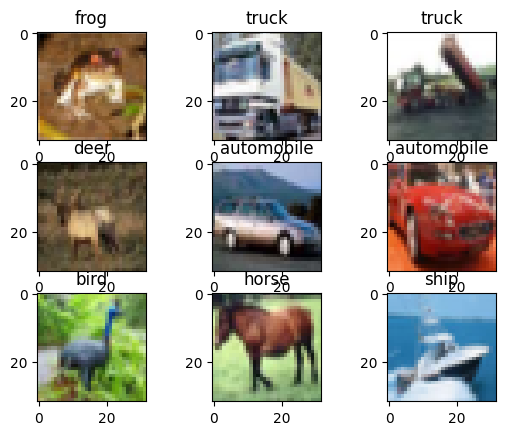

In [4]:
# 데이터셋 정의 -> cifar-10
train_data = datasets.cifar.CIFAR10(
    './data/', 
    train=True, 
    download=True, 
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

'''
다음과 같이 정의하여 함수형태로 후처리도 가능합니다

transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = data_transform(train_data)
'''


test_data = datasets.cifar.CIFAR10(
    root="../data/",
    train=False,
    download=True,
    transform=transforms.ToTensor())

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i])
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

In [16]:
from torch.utils.data import Dataset

class CustomCIFAR10(Dataset):
    def __init__(self, root, train=True, download=False):
        # self.base_dataset = dataset.load_dataset(path = '')
        self.base_dataset = datasets.cifar.CIFAR10(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        # train용 transform
        self.train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5, 0.5, 0.5),
                (0.5, 0.5, 0.5)
            )
        ])

        # test용 transform
        self.test_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5, 0.5, 0.5),
                (0.5, 0.5, 0.5)
            )
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]  # numpy array (H, W, C)
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.transform(image)
        else:
            image = self.test_transform(image)

        return image, label

# 인스턴스 생성
train_data = CustomCIFAR10(root='./data/', train=True, download=True)
test_data = CustomCIFAR10(root='./data/', train=False, download=True)

## Modeling

In [6]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''
    
    def forward(self, x): 
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

        # return self.model(x)

In [7]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()
        
        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)
        
        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)
        
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로
        
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        
        return x

In [17]:
test_data = CustomCIFAR10(
    root='./data/',
    train=False,
    download=True
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

In [39]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cpu


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=4096, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256,

In [42]:
# Learning rate
lr = 1e-3

# Optimizer
optim = Adam(model.parameters(), lr=lr)

adam_train_losses = []

# Train loop
for epoch in range(10):
    for data, label in tqdm(train_loader_v2): # read data
        optim.zero_grad() # Iniitlaization
        
        preds = model(data.to(device)) # prediction
        
        # Loss Function
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

        adam_train_losses.append(
                loss
            )
    
    if epoch==0 or epoch%10==9: # 10번마다 손실 출력
        print(f"epoch{epoch+1} loss:{loss.item()}")
        
# 모델 저장
torch.save(model.state_dict(), "CIFAR.pth")

100%|██████████| 782/782 [01:52<00:00,  6.93it/s]


epoch1 loss:1.6219377517700195


100%|██████████| 782/782 [02:07<00:00,  6.12it/s]

epoch10 loss:0.7961314916610718


In [19]:
data, label = next(iter(test_loader))

print(data.dtype)
print(data.shape)
print(data.min(), data.max())

torch.float32
torch.Size([64, 3, 32, 32])
tensor(-1.) tensor(1.)


In [20]:
model.load_state_dict(torch.load("CIFAR.pth", map_location=device))

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:08<00:00, 18.74it/s]

Accuracy:0.8426


## Experiment 1. Optimizer 변경: Adam → SGD + Momentum

기존 모델에서는 Adam optimizer를 사용하였다.
이번 실험에서는 CNN 구조와 데이터는 동일하게 유지하고,
optimizer만 SGD + Momentum으로 변경하여 학습 양상의 차이를 비교한다.

- 기존: Adam, learning rate = 0.001
- 변경: SGD + Momentum, learning rate = 0.01, momentum = 0.9
- Epoch: 10

In [21]:
# Experiment 1: SGD + Momentum

# 기존에 학습된 model과 분리하기 위해 새로운 CNN 모델 생성
model_sgd = CNN(num_classes=10).to(device)

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer: SGD + Momentum
lr = 1e-2

optim_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=lr,
    momentum=0.9
)

# 학습 과정을 기록하기 위한 리스트
sgd_train_losses = []

print(model_sgd)
print(f"Optimizer: {optim_sgd}")

CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=4096, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256,

In [25]:
from torch.utils.data import Dataset

class CustomCIFAR10_v2(Dataset):
    def __init__(self, root, train=True, download=False):
        self.base_dataset = datasets.CIFAR10(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.train_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5, 0.5, 0.5),
                (0.5, 0.5, 0.5)
            )
        ])

        self.test_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(),
            transforms.Normalize(
                (0.5, 0.5, 0.5),
                (0.5, 0.5, 0.5)
            )
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.train_transform(image)
        else:
            image = self.test_transform(image)

        return image, label

In [26]:
train_data_v2 = CustomCIFAR10_v2(
    root='./data/',
    train=True,
    download=True
)

test_data_v2 = CustomCIFAR10_v2(
    root='./data/',
    train=False,
    download=True
)

train_loader_v2 = DataLoader(
    train_data_v2,
    batch_size=64,
    shuffle=True
)

test_loader_v2 = DataLoader(
    test_data_v2,
    batch_size=64,
    shuffle=False
)

In [27]:
data, label = next(iter(train_loader_v2))

print(data.dtype)
print(data.shape)
print(data.min(), data.max())

torch.float32
torch.Size([64, 3, 32, 32])
tensor(-1.) tensor(1.)


In [28]:
data, label = next(iter(test_loader_v2))

print(data.dtype)
print(data.shape)
print(data.min(), data.max())

torch.float32
torch.Size([64, 3, 32, 32])
tensor(-1.) tensor(1.)


In [30]:
# SGD + Momentum 학습

num_epochs = 10

for epoch in range(num_epochs):
    
    # 학습 모드
    model_sgd.train()
    
    running_loss = 0.0
    
    for data, label in tqdm(train_loader_v2):
        
        # 데이터를 device로 이동
        data = data.to(device)
        label = label.to(device)
        
        # 이전 gradient 초기화
        optim_sgd.zero_grad()
        
        # Forward propagation
        preds = model_sgd(data)
        
        # Loss 계산
        loss = criterion(preds, label)
        
        # Backpropagation
        loss.backward()
        
        # Parameter update
        optim_sgd.step()
        
        # 현재 batch의 loss 누적
        running_loss += loss.item()
    
    # 한 epoch의 평균 loss
    epoch_loss = running_loss / len(train_loader_v2)
    
    # 기록
    sgd_train_losses.append(epoch_loss)
    
    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

100%|██████████| 782/782 [02:43<00:00,  4.79it/s]


Epoch [1/10] Loss: 2.2925


100%|██████████| 782/782 [01:52<00:00,  6.94it/s]


Epoch [2/10] Loss: 1.9115


100%|██████████| 782/782 [02:10<00:00,  6.00it/s]


...

Epoch [8/10] Loss: 0.7728


100%|██████████| 782/782 [02:02<00:00,  6.38it/s]


Epoch [9/10] Loss: 0.6935


100%|██████████| 782/782 [01:57<00:00,  6.64it/s]

Epoch [10/10] Loss: 0.6294


In [31]:
# SGD + Momentum 모델 평가

model_sgd.eval()

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        
        data = data.to(device)
        label = label.to(device)
        
        output = model_sgd(data)
        
        # 가장 높은 logit을 가진 class 선택
        preds = output.argmax(dim=1)
        
        # 정답 개수
        num_corr += (preds == label).sum().item()

sgd_accuracy = num_corr / len(test_data)

print(f"SGD + Momentum Test Accuracy: {sgd_accuracy:.4f}")

100%|██████████| 157/157 [00:07<00:00, 22.35it/s]

SGD + Momentum Test Accuracy: 0.7837


## Experiment 2. Batch Normalization

기존 CNN의 convolution layer 뒤에 Batch Normalization을 추가하였다.

기존 구조:
Conv → ReLU → Conv → ReLU → MaxPool

변경 구조:
Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU → MaxPool

다른 모델 구조와 optimizer는 동일하게 유지하여
Batch Normalization이 학습 속도와 성능에 미치는 영향을 비교한다.

- Optimizer: Adam
- Learning rate: 0.001
- Epoch: 10

In [32]:
class BasicBlockBN(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        hidden_dim
    ):
        super().__init__()

        # 첫 번째 convolution
        self.conv1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=hidden_dim,
            kernel_size=3,
            padding=1
        )

        # 첫 번째 Batch Normalization
        self.bn1 = nn.BatchNorm2d(hidden_dim)

        # 두 번째 convolution
        self.conv2 = nn.Conv2d(
            in_channels=hidden_dim,
            out_channels=out_channels,
            kernel_size=3,
            padding=1
        )

        # 두 번째 Batch Normalization
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.pool(x)

        return x

In [33]:
class CNN_BN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.block1 = BasicBlockBN(
            in_channels=3,
            out_channels=32,
            hidden_dim=16
        )

        self.block2 = BasicBlockBN(
            in_channels=32,
            out_channels=128,
            hidden_dim=64
        )

        self.block3 = BasicBlockBN(
            in_channels=128,
            out_channels=256,
            hidden_dim=128
        )

        self.fc1 = nn.Linear(
            in_features=4096,
            out_features=2048
        )

        self.fc2 = nn.Linear(
            in_features=2048,
            out_features=256
        )

        self.fc3 = nn.Linear(
            in_features=256,
            out_features=num_classes
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = torch.flatten(
            x,
            start_dim=1
        )

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)
        x = self.relu(x)

        x = self.fc3(x)

        return x

In [34]:
# BatchNorm 모델 새로 생성
model_bn = CNN_BN(
    num_classes=10
).to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# 기존 baseline과 동일하게 Adam 사용
optim_bn = torch.optim.Adam(
    model_bn.parameters(),
    lr=1e-3
)

# epoch별 평균 loss 저장
bn_train_losses = []

print(model_bn)

CNN_BN(
  (block1): BasicBlockBN(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlockBN(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

In [35]:
num_epochs = 10

for epoch in range(num_epochs):

    # 매우 중요
    model_bn.train()

    running_loss = 0.0

    for data, label in tqdm(train_loader_v2):

        data = data.to(device)
        label = label.to(device)

        # gradient 초기화
        optim_bn.zero_grad()

        # Forward
        preds = model_bn(data)

        # Loss
        loss = criterion(
            preds,
            label
        )

        # Backward
        loss.backward()

        # Parameter update
        optim_bn.step()

        running_loss += loss.item()

    # epoch 평균 loss
    epoch_loss = (
        running_loss
        / len(train_loader_v2)
    )

    bn_train_losses.append(
        epoch_loss
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

100%|██████████| 782/782 [02:55<00:00,  4.46it/s]


Epoch [1/10] Loss: 1.5533


100%|██████████| 782/782 [03:15<00:00,  3.99it/s]


Epoch [2/10] Loss: 1.0713


100%|██████████| 782/782 [02:50<00:00,  4.59it/s]


...

Epoch [8/10] Loss: 0.5072


100%|██████████| 782/782 [03:45<00:00,  3.46it/s]


Epoch [9/10] Loss: 0.4750


100%|██████████| 782/782 [03:55<00:00,  3.32it/s]

Epoch [10/10] Loss: 0.4397


In [36]:
model_bn.eval()

num_corr = 0

with torch.no_grad():

    for data, label in tqdm(test_loader_v2):

        data = data.to(device)
        label = label.to(device)

        output = model_bn(data)

        preds = output.argmax(
            dim=1
        )

        num_corr += (
            preds == label
        ).sum().item()

bn_accuracy = (
    num_corr
    / len(test_data_v2)
)

print(
    f"BatchNorm Test Accuracy: "
    f"{bn_accuracy:.4f}"
)

100%|██████████| 157/157 [00:07<00:00, 21.97it/s]

BatchNorm Test Accuracy: 0.8345


In [47]:
# 1. Tensor → Python float 변환
adam_batch_losses = [
    x.detach().cpu().item() if torch.is_tensor(x) else float(x)
    for x in adam_train_losses
]

# 2. 한 epoch에 포함된 batch 수
batches_per_epoch = len(train_loader_v2)

# 3. batch loss → epoch 평균 loss
adam_epoch_losses = []

for i in range(0, len(adam_batch_losses), batches_per_epoch):
    epoch_batch_losses = adam_batch_losses[i:i + batches_per_epoch]

    if len(epoch_batch_losses) == batches_per_epoch:
        epoch_mean = sum(epoch_batch_losses) / len(epoch_batch_losses)
        adam_epoch_losses.append(epoch_mean)

print("Adam epoch losses:", adam_epoch_losses)
print("Adam epochs:", len(adam_epoch_losses))
print("BN epochs:", len(bn_train_losses))

Adam epoch losses: [1.7320750806947498, 1.2891586275051927, 1.046637848515035, 0.9009334360394636, 0.7990821046597513, 0.7356401782511445, 0.6794641041923362, 0.6277894686021463, 0.5921890515348186, 0.5622089094937305]
Adam epochs: 10
BN epochs: 10


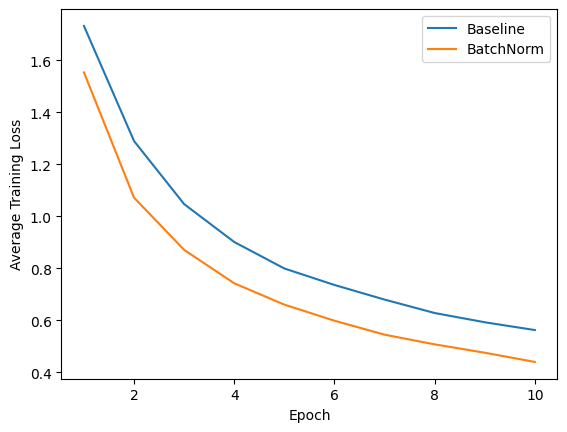

In [48]:
plt.figure()

plt.plot(
    range(1, len(adam_epoch_losses) + 1),
    adam_epoch_losses,
    label="Baseline"
)

plt.plot(
    range(1, len(bn_train_losses) + 1),
    bn_train_losses,
    label="BatchNorm"
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.legend()
plt.show()

- BatchNorm에서 가파른 loss감소를 기대했지만 감소폭에 큰 차이는 없음